In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv(r"C:\Users\Aniket\OneDrive\Desktop\Customer_Segmentation\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df.shape

(200, 5)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [12]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [13]:
df.columns = ["CustomerID", "Gender", "Age", "Annual_Income", "Spending_Score"]
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


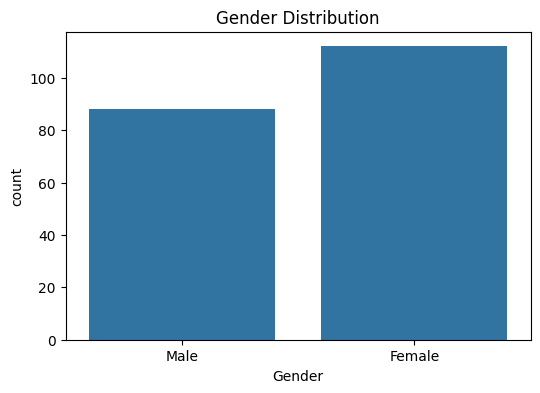

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

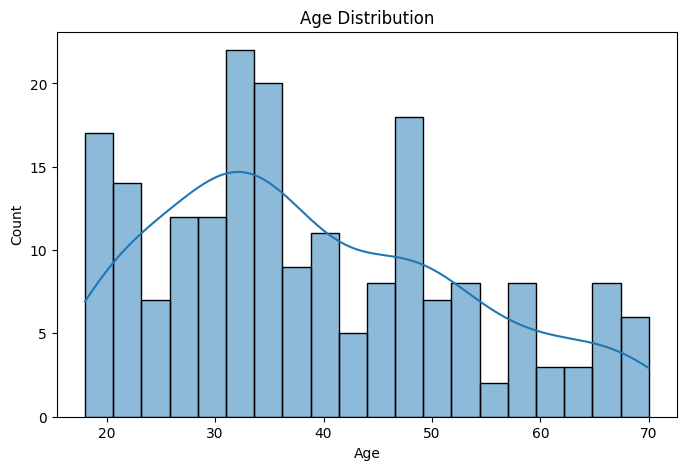

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

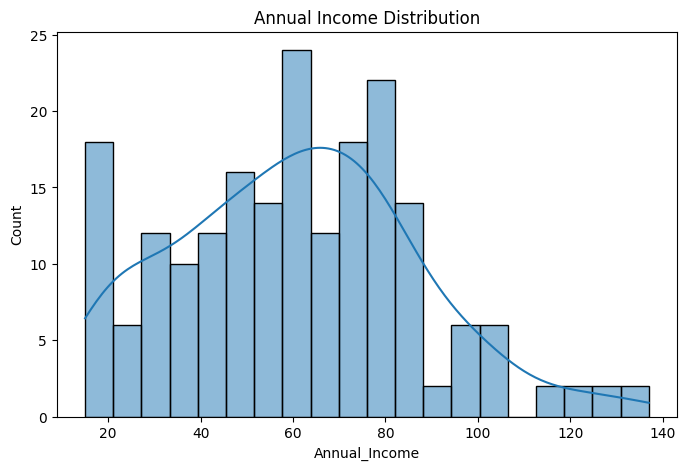

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["Annual_Income"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

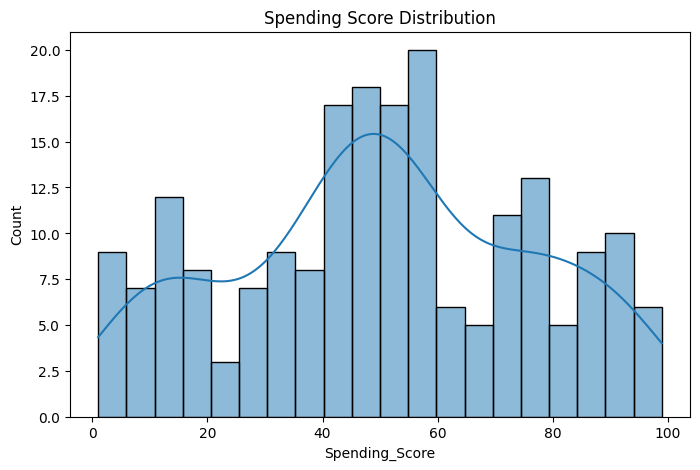

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["Spending_Score"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

In [18]:
X = df[["Annual_Income", "Spending_Score"]]
X.head()

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [19]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

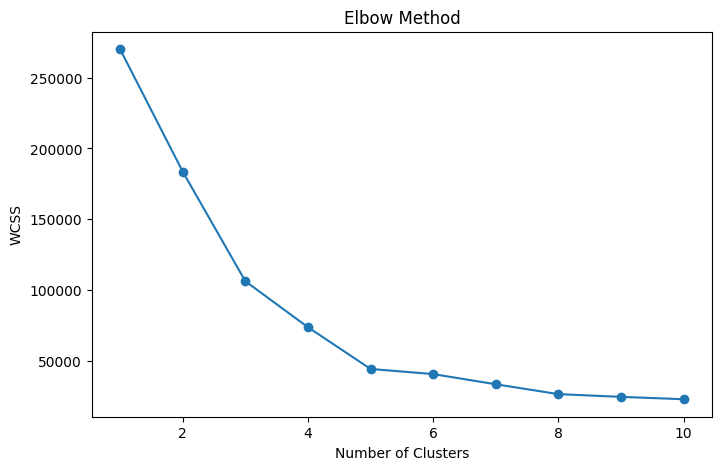

In [20]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [21]:
kmeans = KMeans(n_clusters=5, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


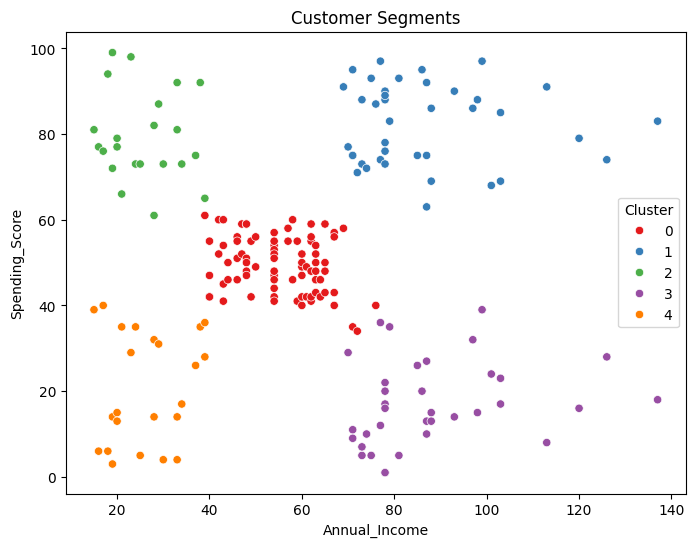

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="Cluster",
    palette="Set1",
    data=df
)

plt.title("Customer Segments")
plt.show()

In [23]:
centers = kmeans.cluster_centers_
centers

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [24]:
for i in range(5):
    print(f"\nCluster {i} Summary:")
    print(df[df["Cluster"] == i][["Annual_Income", "Spending_Score"]].mean())


Cluster 0 Summary:
Annual_Income     55.296296
Spending_Score    49.518519
dtype: float64

Cluster 1 Summary:
Annual_Income     86.538462
Spending_Score    82.128205
dtype: float64

Cluster 2 Summary:
Annual_Income     25.727273
Spending_Score    79.363636
dtype: float64

Cluster 3 Summary:
Annual_Income     88.200000
Spending_Score    17.114286
dtype: float64

Cluster 4 Summary:
Annual_Income     26.304348
Spending_Score    20.913043
dtype: float64


In [28]:
df.to_csv("segmented_customers.csv", index=False)
print("File saved successfully!")

File saved successfully!
